In [1]:
import os
import sys
from pathlib import Path

sys.path.insert(0, '../../')
import numpy as np
from matplotlib import pyplot as plt

import lsstypes as types
from clustering_statistics import tools, box_tools

### ELG

In [7]:
dirname = Path('/pscratch/sd/a/adematti/measurements/angular_shotnoise')

region = 'SGC'
stats = ['mesh2_spectrum', 'mesh3_spectrum']
imweights = ['WEIGHT_SYS', 'WEIGHT_IMLIN', 'WEIGHT_IMLIN_DES']
randomizes = ['constant', 'isotropic', 'angular', 'isotropic_norm', 'angular_norm'][:1]
norm_regions_list = ['NS', 'NSnoDESDES'][1:]
tracer = 'ELG_LOPnotqso'
spectra = {}
for stat in stats:
    for norm_regions in norm_regions_list:
        for imweight in imweights:
            for randomize in [None] + randomizes:
                if randomize is not None and imweight != 'WEIGHT_IMLIN_DES':
                    continue  # randomize shown for WEIGHT_IMLIN_DES only
                randomize_label = f'_randomize-{randomize}' if randomize else ''
                fn = dirname / f'{stat}_{tracer}_{region}_{imweight}_norm{norm_regions}{randomize_label}.h5'
                spectrum = types.read(fn)
                if stat == 'mesh2_spectrum':
                    spectrum = spectrum.select(k=slice(0, None, 5))
                spectra[stat, norm_regions, imweight, randomize] = spectrum

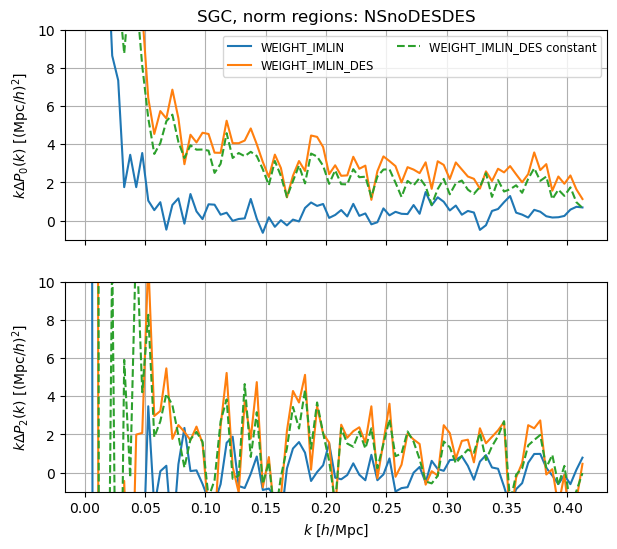

In [8]:
for norm_regions in norm_regions_list:
    ells = spectra['mesh2_spectrum', norm_regions, 'WEIGHT_SYS', None].ells[:2]
    fig, lax = plt.subplots(len(ells), sharex=True, figsize=(7., 6.))
    lax = lax.ravel()
    for ill, ell in enumerate(ells):
        ax = lax[ill]
        ref = spectra['mesh2_spectrum', norm_regions, 'WEIGHT_SYS', None].get(ell)
        k = ref.coords('k')
        test = spectra['mesh2_spectrum', norm_regions, 'WEIGHT_IMLIN', None].get(ell)
        #ax.plot(k, k * (test.value() + test.values('shotnoise') - (ref.value() + ref.values('shotnoise')), color='C0', label='WEIGHT_IMLIN')
        ax.plot(k, k * (test.value() - ref.value()), color='C0', label='WEIGHT_IMLIN')
        test = spectra['mesh2_spectrum', norm_regions, 'WEIGHT_IMLIN_DES', None].get(ell)
        #ax.plot(k, k * (test.value() + test.values('shotnoise') - (ref.value() + ref.values('shotnoise')), color='C1', label='WEIGHT_IMLIN_DES')
        ax.plot(k, k * (test.value() - ref.value()), color='C1', label='WEIGHT_IMLIN_DES')
        for irandomize, randomize in enumerate(randomizes):
            ax.plot(k, k * (spectra['mesh2_spectrum', norm_regions, 'WEIGHT_IMLIN_DES', randomize].get(ell).value() - ref.value()),
                    color=f'C{2 + irandomize:d}', linestyle='--', label=f'WEIGHT_IMLIN_DES {randomize}')
        ax.set_ylabel(rf'$k \Delta P_{ell:d}(k)$ [$(\mathrm{{Mpc}}/h)^2$]')
        ax.set_ylim(-1., 10.)
        ax.grid(True)
    lax[0].legend(fontsize='small', ncols=2)
    lax[0].set_title(f'{tracer} {region}, norm regions: {norm_regions}')
    lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
    plt.show()

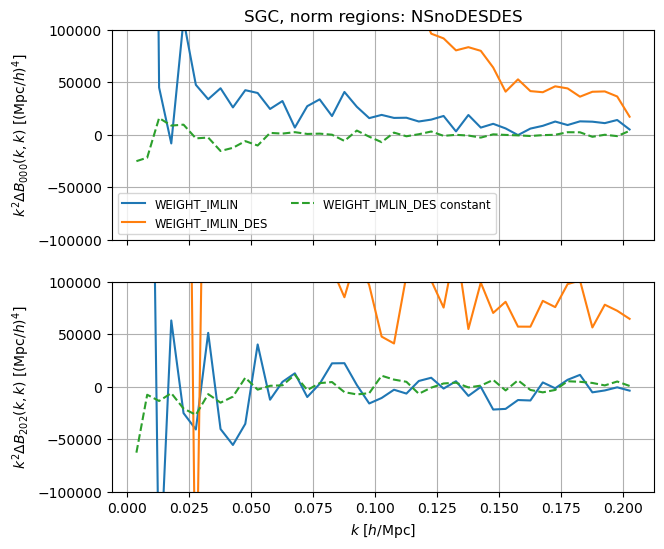

In [6]:
for norm_regions in norm_regions_list:
    ells = spectra['mesh3_spectrum', norm_regions, 'WEIGHT_SYS', None].ells
    fig, lax = plt.subplots(len(ells), sharex=True, figsize=(7., 6.))
    lax = lax.ravel()
    for ill, ell in enumerate(ells):
        ax = lax[ill]
        ref = spectra['mesh3_spectrum', norm_regions, 'WEIGHT_SYS', None].get(ell)
        k = ref.coords('k')[..., 0]
        test = spectra['mesh3_spectrum', norm_regions, 'WEIGHT_IMLIN', None].get(ell)
        ax.plot(k, k**2 * (test.value() - ref.value()), color='C0', label='WEIGHT_IMLIN')
        #ax.plot(k, k**2 * ((test.value() + test.values('shotnoise')) - (ref.value() + ref.values('shotnoise'))), color='C0', label='WEIGHT_IMLIN')
        test = spectra['mesh3_spectrum', norm_regions, 'WEIGHT_IMLIN_DES', None].get(ell)
        ax.plot(k, k**2 * (test.value() - ref.value()), color='C1', label='WEIGHT_IMLIN_DES')
        #ax.plot(k, k**2 * ((test.value() + test.values('shotnoise')) - (ref.value() + ref.values('shotnoise'))), color='C1', label='WEIGHT_IMLIN_DES')
        for irandomize, randomize in enumerate(randomizes):
            ax.plot(k, k**2 * (spectra['mesh3_spectrum', norm_regions, 'WEIGHT_IMLIN_DES', randomize].get(ell).value() - ref.value()),
                    color=f'C{2 + irandomize:d}', linestyle='--', label=f'WEIGHT_IMLIN_DES {randomize}')
        ax.set_ylabel(rf'$k^2 \Delta B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}}(k, k)$ [$(\mathrm{{Mpc}}/h)^4$]')
        ax.set_ylim(-1e5, 1e5)
        ax.grid(True)
    lax[0].legend(fontsize='small', ncols=2)
    lax[0].set_title(f'{tracer} {region}, norm regions: {norm_regions}')
    lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
    plt.show()

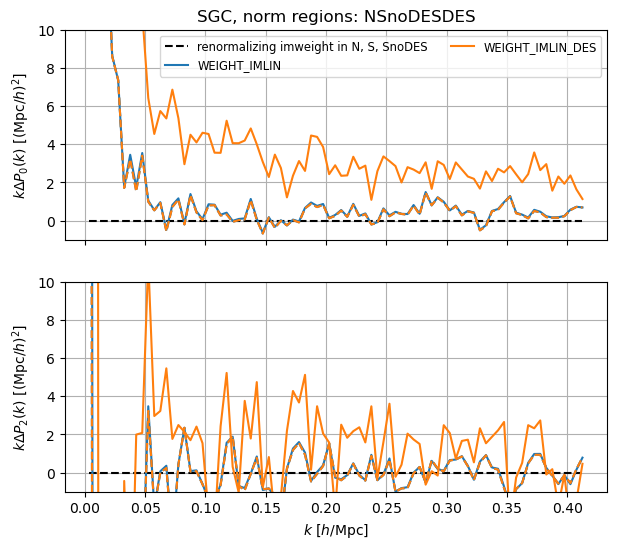

In [34]:
norm_regions = 'NSnoDESDES'
for stat in ['mesh2_spectrum', 'mesh3_spectrum']:
    for imweight in ['WEIGHT_SYS', 'WEIGHT_IMLIN', 'WEIGHT_IMLIN_DES']:
        fn = dirname / f'{stat}_{tracer}_{region}_{imweight}_norm{norm_regions}_renorm-imweight.h5'
        spectra[stat, norm_regions, imweight, 'renorm'] = types.read(fn).match(spectra[stat, norm_regions, 'WEIGHT_SYS', None])

ells = spectra['mesh2_spectrum', norm_regions, 'WEIGHT_SYS', None].ells[:2]
fig, lax = plt.subplots(len(ells), sharex=True, figsize=(7., 6.))
lax = lax.ravel()
for ill, ell in enumerate(ells):
    ax = lax[ill]
    ref = spectra['mesh2_spectrum', norm_regions, 'WEIGHT_SYS', None].get(ell)
    k = ref.coords('k')
    test = spectra['mesh2_spectrum', norm_regions, 'WEIGHT_SYS', 'renorm'].get(ell)
    ax.plot(k, k * (test.value() - ref.value()), color='k', linestyle='--', label='renormalizing imweight in N, S, SnoDES')
    test = spectra['mesh2_spectrum', norm_regions, 'WEIGHT_IMLIN', None].get(ell)
    ax.plot(k, k * (test.value() - ref.value()), color='C0', label='WEIGHT_IMLIN')
    test = spectra['mesh2_spectrum', norm_regions, 'WEIGHT_IMLIN', 'renorm'].get(ell)
    ax.plot(k, k * (test.value() - ref.value()), color='C0', linestyle='--')
    test = spectra['mesh2_spectrum', norm_regions, 'WEIGHT_IMLIN_DES', None].get(ell)
    ax.plot(k, k * (test.value() - ref.value()), color='C1', label='WEIGHT_IMLIN_DES')
    test = spectra['mesh2_spectrum', norm_regions, 'WEIGHT_IMLIN', 'renorm'].get(ell)
    ax.plot(k, k * (test.value() - ref.value()), color='C1', linestyle='--')
    ax.set_ylabel(rf'$k \Delta P_{ell:d}(k)$ [$(\mathrm{{Mpc}}/h)^2$]')
    ax.set_ylim(-1., 10.)
    ax.grid(True)
lax[0].legend(fontsize='small', ncols=2)
lax[0].set_title(f'{region}, norm regions: {norm_regions}')
lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
plt.show()

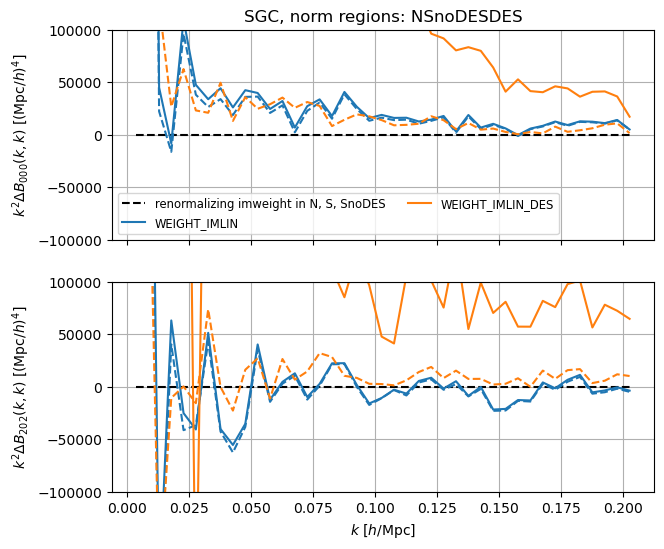

In [41]:
norm_regions = 'NSnoDESDES'
ells = spectra['mesh3_spectrum', norm_regions, 'WEIGHT_SYS', None].ells
fig, lax = plt.subplots(len(ells), sharex=True, figsize=(7., 6.))
lax = lax.ravel()
for ill, ell in enumerate(ells):
    ax = lax[ill]
    ref = spectra['mesh3_spectrum', norm_regions, 'WEIGHT_SYS', None].get(ell)
    k = ref.coords('k')[..., 0]
    test = spectra['mesh3_spectrum', norm_regions, 'WEIGHT_SYS', 'renorm'].get(ell)
    ax.plot(k, k**2 * (test.value() - ref.value()), color='k', linestyle='--', label='renormalizing imweight in N, S, SnoDES')
    test = spectra['mesh3_spectrum', norm_regions, 'WEIGHT_IMLIN', None].get(ell)
    ax.plot(k, k**2 * (test.value() - ref.value()), color='C0', label='WEIGHT_IMLIN')
    test = spectra['mesh3_spectrum', norm_regions, 'WEIGHT_IMLIN', 'renorm'].get(ell)
    ax.plot(k, k**2 * (test.value() - ref.value()), color='C0', linestyle='--')
    test = spectra['mesh3_spectrum', norm_regions, 'WEIGHT_IMLIN_DES', None].get(ell)
    ax.plot(k, k**2 * (test.value() - ref.value()), color='C1', label='WEIGHT_IMLIN_DES')
    test = spectra['mesh3_spectrum', norm_regions, 'WEIGHT_IMLIN_DES', 'renorm'].get(ell)
    ax.plot(k, k**2 * (test.value() - ref.value()), color='C1', linestyle='--')
    ax.set_ylabel(rf'$k^2 \Delta B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}}(k, k)$ [$(\mathrm{{Mpc}}/h)^4$]')
    ax.set_ylim(-1e5, 1e5)
    ax.grid(True)
lax[0].legend(fontsize='small', ncols=2)
lax[0].set_title(f'{region}, norm regions: {norm_regions}')
lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
plt.show()

In [3]:
from mpytools import Catalog

cat_dir = tools.desi_dir / 'survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/fNL'
print(cat_dir)

def get_catalog_fn(kind='data', tracer='ELG_LOPnotqso', region='NGC', iran=0):
    """Return fNL clustering catalog filename."""
    if kind == 'data':
        return cat_dir / f'{tracer}_{region}_clustering.dat.fits'
    return cat_dir / f'{tracer}_{region}_{iran:d}_clustering.ran.fits'

fn = get_catalog_fn(tracer=tracer, region='SGC')
data = Catalog.read(fn)

weights = ['WEIGHT_SYS', 'WEIGHT_IMLIN', 'WEIGHT_IMLIN_DES'][:1]
#for weight in weights:
#    data[weight] = np.clip(data[weight], 0., 5.)

/dvs_ro/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/fNL
['TARGETID', 'TILEID', 'NTILE', 'RA', 'DEC', 'PHOTSYS', 'Z', 'FRAC_TLOBS_TILES', 'WEIGHT_ZFAIL', 'WEIGHT_IMLIN', 'WEIGHT_SYS', 'WEIGHT', 'WEIGHT_COMP', 'NX', 'WEIGHT_FKP', 'WEIGHT_IMLIN_ALLEBVCMB']


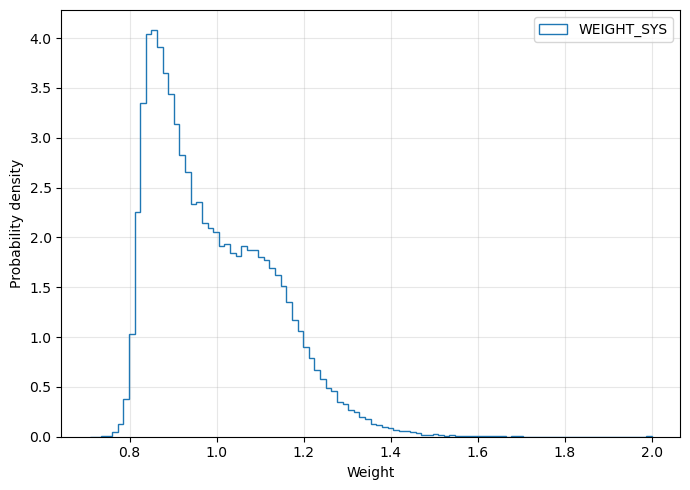

In [37]:

# Weight distributions
fig, ax = plt.subplots(figsize=(7, 5))

for name in weights:
    values = np.asarray(data[name])
    mask = np.isfinite(values)
    ax.hist(values[mask], bins=100, histtype='step', density=True, label=name)

ax.set_xlabel('Weight')
ax.set_ylabel('Probability density')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


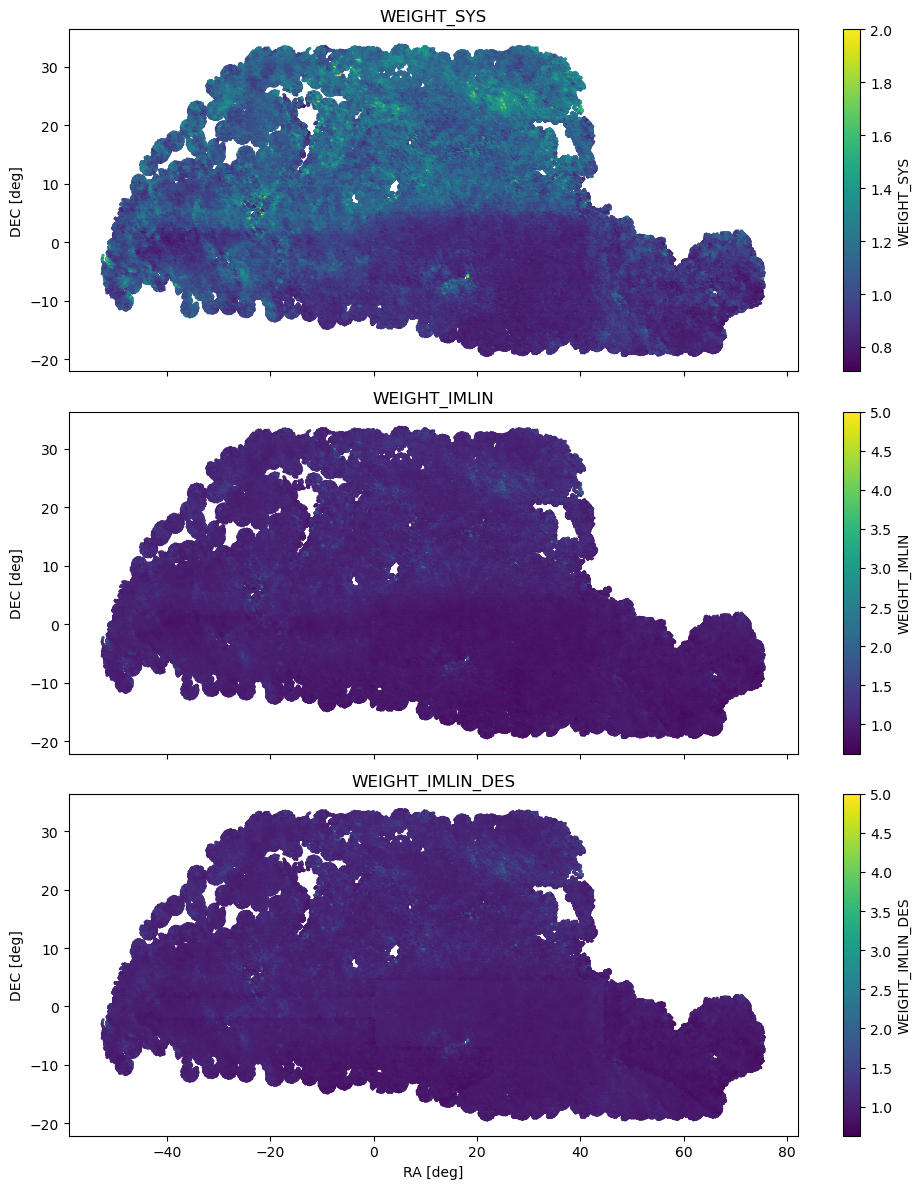

In [30]:
# RA-DEC maps
fig, axes = plt.subplots(len(weights), 1, figsize=(10, 4 * len(weights)),
                         sharex=True, sharey=True)

ra = np.asarray(data['RA'])
ra = (ra + 180.) % 360. - 180.
dec = np.asarray(data['DEC'])

for ax, name in zip(axes, weights):
    values = np.asarray(data[name])
    mask = np.isfinite(ra) & np.isfinite(dec) & np.isfinite(values)

    sc = ax.scatter(ra[mask], dec[mask], c=values[mask], s=1, rasterized=True)
    fig.colorbar(sc, ax=ax, label=name)

    ax.set_ylabel('DEC [deg]')
    ax.set_title(name)

axes[-1].set_xlabel('RA [deg]')

plt.tight_layout()
plt.show()

### QSO

In [14]:
dirname = Path('/pscratch/sd/a/adematti/measurements/angular_shotnoise')

region = 'SGC'
stats = ['mesh2_spectrum', 'mesh3_spectrum']
imweights = ['WEIGHT_SYS', 'WEIGHT_ONE']
randomizes = ['constant', 'isotropic', 'angular', 'isotropic_norm', 'angular_norm'][:1]
norm_regions_list = ['NS', 'NSnoDESDES'][1:]
tracer = 'QSO'

spectra = {}
for stat in stats:
    for norm_regions in norm_regions_list:
        for imweight in imweights:
            for randomize in [None] + randomizes:
                if randomize is not None and imweight != 'WEIGHT_ONE':
                    continue  # randomize shown for WEIGHT_ONE only
                randomize_label = f'_randomize-{randomize}' if randomize else ''
                fn = dirname / f'{stat}_{tracer}_{region}_{imweight}_norm{norm_regions}{randomize_label}.h5'
                spectrum = types.read(fn)
                if stat == 'mesh2_spectrum':
                    spectrum = spectrum.select(k=slice(0, None, 5))
                spectra[stat, norm_regions, imweight, randomize] = spectrum

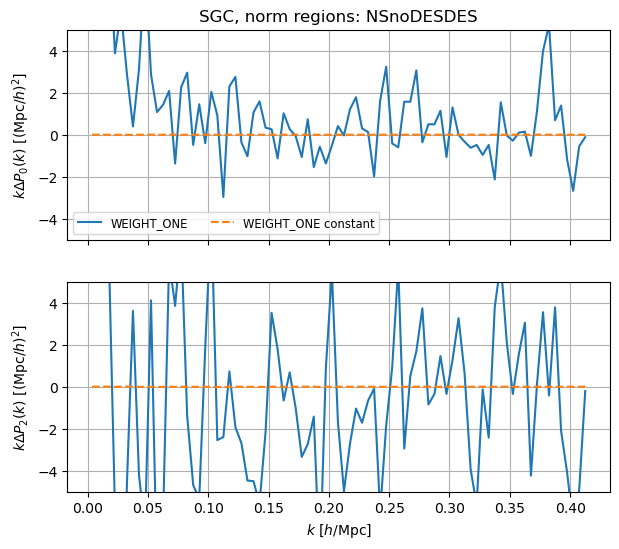

In [15]:
for norm_regions in norm_regions_list:
    ells = spectra['mesh2_spectrum', norm_regions, 'WEIGHT_SYS', None].ells[:2]
    fig, lax = plt.subplots(len(ells), sharex=True, figsize=(7., 6.))
    lax = lax.ravel()
    for ill, ell in enumerate(ells):
        ax = lax[ill]
        ref = spectra['mesh2_spectrum', norm_regions, 'WEIGHT_SYS', None].get(ell)
        k = ref.coords('k')
        test = spectra['mesh2_spectrum', norm_regions, 'WEIGHT_ONE', None].get(ell)
        ax.plot(k, k * (test.value() - ref.value()), color='C0', label='WEIGHT_ONE')
        for irandomize, randomize in enumerate(randomizes):
            ax.plot(k, k * (spectra['mesh2_spectrum', norm_regions, 'WEIGHT_ONE', randomize].get(ell).value() - ref.value()),
                    color=f'C{1 + irandomize:d}', linestyle='--', label=f'WEIGHT_ONE {randomize}')
        ax.set_ylabel(rf'$k \Delta P_{ell:d}(k)$ [$(\mathrm{{Mpc}}/h)^2$]')
        ax.set_ylim(-5., 5.)
        ax.grid(True)
    lax[0].legend(fontsize='small', ncols=2)
    lax[0].set_title(f'{region}, norm regions: {norm_regions}')
    lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
    plt.show()

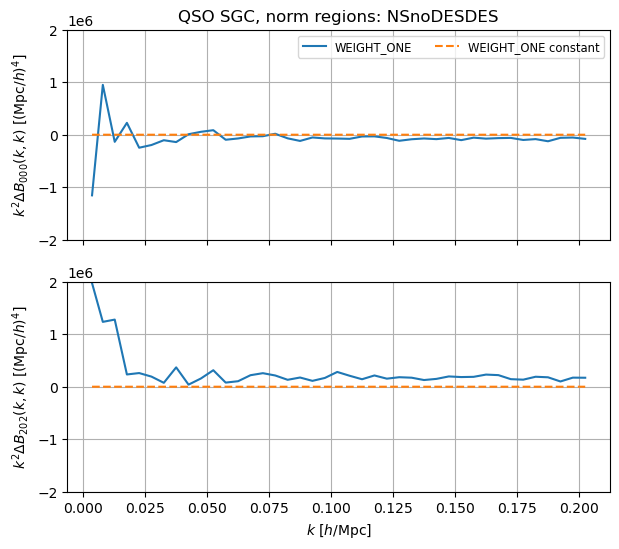

In [16]:
for norm_regions in norm_regions_list:
    ells = spectra['mesh3_spectrum', norm_regions, 'WEIGHT_SYS', None].ells
    fig, lax = plt.subplots(len(ells), sharex=True, figsize=(7., 6.))
    lax = lax.ravel()
    for ill, ell in enumerate(ells):
        ax = lax[ill]
        ref = spectra['mesh3_spectrum', norm_regions, 'WEIGHT_SYS', None].get(ell)
        k = ref.coords('k')[..., 0]
        test = spectra['mesh3_spectrum', norm_regions, 'WEIGHT_ONE', None].get(ell)
        ax.plot(k, k**2 * (test.value() - ref.value()), color='C0', label='WEIGHT_ONE')
        for irandomize, randomize in enumerate(randomizes):
            ax.plot(k, k**2 * (spectra['mesh3_spectrum', norm_regions, 'WEIGHT_ONE', randomize].get(ell).value() - ref.value()),
                    color=f'C{1 + irandomize:d}', linestyle='--', label=f'WEIGHT_ONE {randomize}')
        ax.set_ylabel(rf'$k^2 \Delta B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}}(k, k)$ [$(\mathrm{{Mpc}}/h)^4$]')
        ax.set_ylim(-2e6, 2e6)
        ax.grid(True)
    lax[0].legend(fontsize='small', ncols=2)
    lax[0].set_title(f'{tracer} {region}, norm regions: {norm_regions}')
    lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
    plt.show()